In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle
import emcee
import sys
import numpy as np
import seaborn as sns
import afterglowpy as grb
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

from astropy.cosmology import Planck18 as cosmo
from astropy.time import Time
from getdist import plots, MCSamples

In [3]:
sys.path.append('/home/masson/afterglowpy/orphan_modules')
from plotting_lc import plot_pseudo_obs

In [4]:
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

In [5]:
# import orphan afterglow light curves
file_open = open('/home/masson/afterglowpy/data/orphans_pseudo_obs_5pts_low_redshift.pkl', 'rb')
orphans = pickle.load(file_open)
file_open.close()

## Choose an orphan to fit

In [6]:
oa = orphans[5]

/home/masson/anaconda3/envs/orphans/lib/python3.9/site-packages/erfa/core.py:154: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),


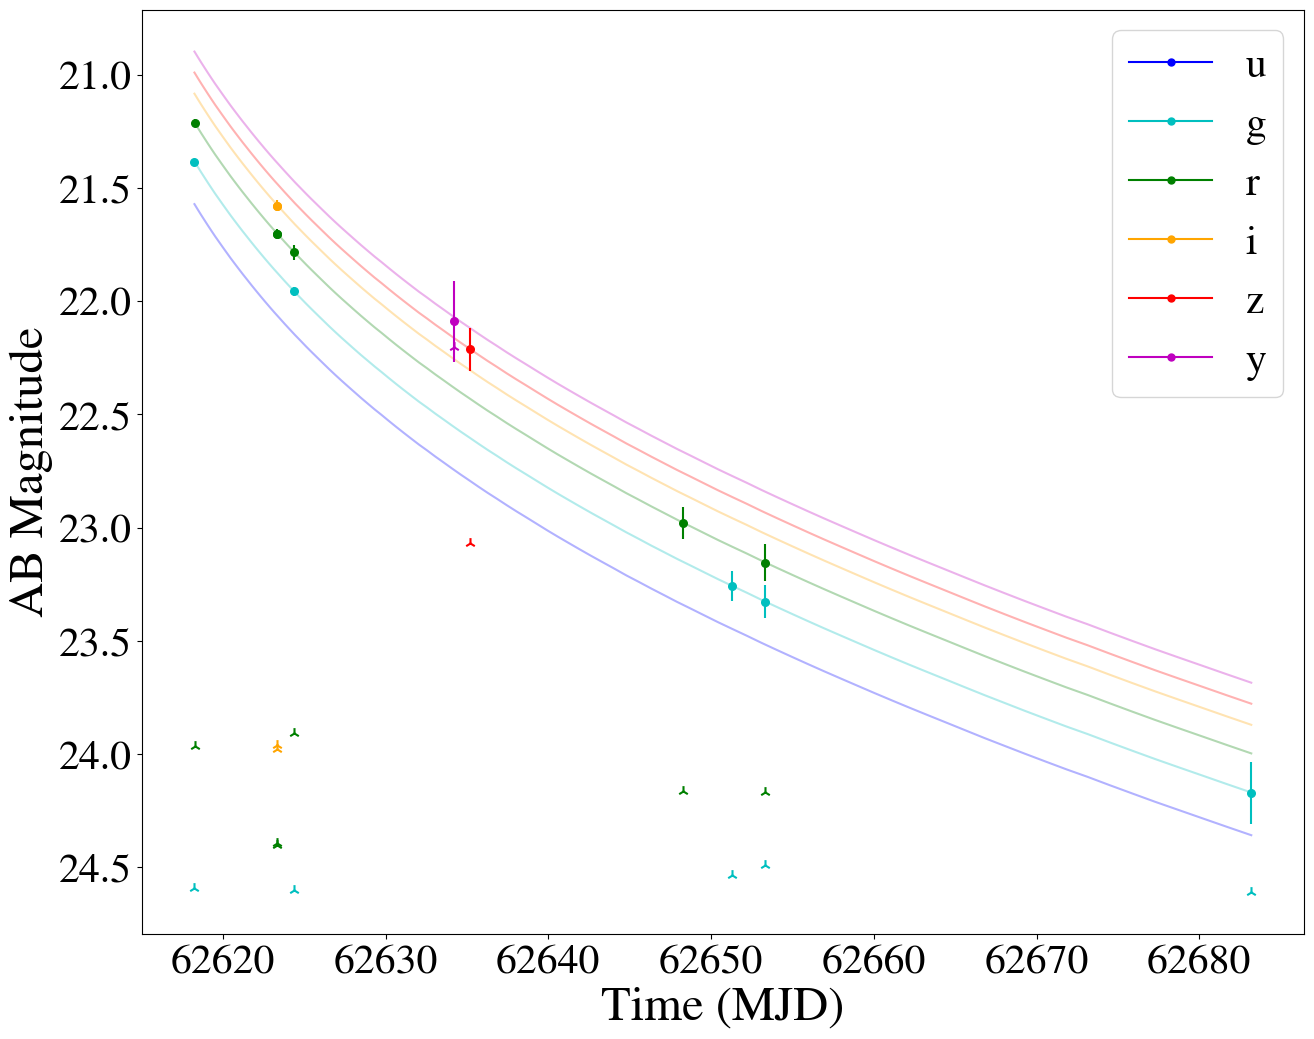

In [7]:
plot_pseudo_obs(oa, extinction=False)

## Define some functions

In [8]:
def flux_to_mag(flux):
    """ Convert flux from milliJansky to AB Magnitude

    1 Jy = 1e-23 erg/cm2/s/Hz
    Fnu = 3631 Jy = 3.631*1e-20 erg/cm2/s/Hz
    ABmag = 0-2.5*log10( Fnu )-48.6 = 0

    :param flux: flux in milli-Jansky
    :return: mag: as the AB Magnitude
    """

    mag = -2.5 * np.log10(flux * 1.0e-26) - 48.6
    return mag


def mag_to_flux(mag):
    """ Convert flux from AB Magnitude to milliJansky

    1 Jy = 1e-23 erg/cm2/s/Hz
    Fnu = 3631 Jy = 3.631*1e-20 erg/cm2/s/Hz
    ABmag = 0-2.5*log10( Fnu )-48.6 = 0

    :param mag: as the AB Magnitude
    :return: flux: flux in milli-Jansky
    """

    flux = pow(10, (26 - (mag + 48.6) / 2.5))
    return flux


def rescale_filters(times, mags, mags_err, filts):
    """
    Rescale magnitudes from all filters to the r-band, keeping array order.

    Parameters
    ----------
    times : array
        Observation times
    mags : array
        Observed magnitudes
    mags_err : array
        Magnitude uncertainties
    filts : array
        Filter names as colours: {'u':'b', 'g':'c', 'r':'g', 'i':'orange', 'z':'r', 'Y':'m'}

    Returns
    -------
    times : array
        Same as input
    mags_r : array
        Magnitudes rescaled to r-band
    mags_err : array
        Same errors, in original order
    """

    filters = ['b', 'c', 'g', 'orange', 'r', 'm']
    mean_nus = [840336134453781.4, 629326620516047.8, 482703137570394.2,
                397614314115308.1, 344530577088716.56, 298760145396604.1]

    # Map colour to frequency
    filt_to_nu = dict(zip(filters, mean_nus))

    # Find most common non-r filter to define spectral slope
    filt_obs = filts[filts != 'g']
    if len(filt_obs) == 0:
        return times, mags, mags_err

    unique, counts = np.unique(filt_obs, return_counts=True)
    filt_max = unique[np.argmax(counts)]
    nu_filtmax = filt_to_nu[filt_max]

    # Select data for fitting beta
    mask_r = filts == 'g'
    mask_fmax = filts == filt_max

    flux_r = mag_to_flux(mags[mask_r])
    flux_fmax = mag_to_flux(mags[mask_fmax])
    time_r = times[mask_r]
    time_fmax = times[mask_fmax]

    beta_vals = np.linspace(-0.6, -1.1, 10)
    dists = []

    for b in beta_vals:
        flux_rescaled = flux_fmax * (filt_to_nu['g'] / nu_filtmax) ** b
        dist = np.sum(np.sqrt((time_fmax[:, None] - time_r[None, :]) ** 2 +
                              (flux_rescaled[:, None] - flux_r[None, :]) ** 2))
        dists.append(dist)

    best_beta = beta_vals[np.argmin(dists)]

    # Rescale each point individually
    mags_r = []
    for mag, filt in zip(mags, filts):
        nu = filt_to_nu[filt]
        flux = mag_to_flux(mag)

        if filt != 'g':
            flux_rescaled = flux * (filt_to_nu['g'] / nu) ** best_beta
            mag_rescaled = flux_to_mag(flux_rescaled)
        else:
            mag_rescaled = mag

        mags_r.append(mag_rescaled)

    return times, np.array(mags_r), mags_err

In [9]:
def model(t, nu, params):
    """ Model used to fit, implemented here in the afterglowpy package
    """

    # dictionary containing the fixed parameters
    Z = {'jetType': 4,
         'specType': 0,
         'b': 4,
         'p': 2.2,
         'epsilon_e': 0.1,
         'epsilon_B': 0.01,
         'xi_N': 1.0,
         'z': oa['config']['z'],  # redshift is supposed to be known
         'd_L': cosmo.luminosity_distance(oa['config']['z']).value * 3.08e24}

    # parameters to fit
    T0, logE, thetaObs, thetaCore, thetaWing, logn = params

    return grb.fluxDensity((t - T0) * grb.day2sec, nu, E0=10**logE, thetaObs=thetaObs, thetaCore=thetaCore,
                           thetaWing=thetaWing, n0=10**logn, **Z)


def lnlike(p, t, y, yerr):
    """ Compute ln of likelihood
    """

    return -0.5 * np.sum(((y - model(t, nu, p)) / yerr) ** 2)


def lnprior(p):
    """ Compute ln of parameters priors
    """

    T0, logE, thetaObs, thetaCore, thetaWing, logn = p

    # uniform priors
    if (t[0] - 200. < T0 < t[0] - 1. and 51. < logE < 55. and 0.0 < thetaCore < np.pi / 2 and thetaCore < thetaWing < np.pi / 2 and 0.01 < np.cos(thetaObs) < 0.99 
        and -2 < logn < 2):
        return (0.0)

    return (-np.inf)


def lnpost(p, t, y, yerr):
    """ Compute ln of parameters posteriors
    """

    lp = lnprior(p)

    return lp + lnlike(p, t, y, yerr) if np.isfinite(lp) else -np.inf


def sample_walkers(nsamples, flattened_chain, nu):
    """ Compute the median model and the spread in posteriors of the MCMC
    """

    models = []
    draw = np.floor(np.random.uniform(0, len(flattened_chain), size=nsamples)).astype(int)
    thetas = flattened_chain[draw]

    for i in thetas:
        mod = model(t_fit, nu, i)
        models.append(mod)

    spread = np.std(models, axis=0)
    med_model = np.median(models, axis=0)

    return med_model, spread

## Fit the light curve (MCMC fit with `emcee`)

In [10]:
all_mean_nu = [840336134453781.4, 629326620516047.8, 482703137570394.2, 397614314115308.1, 344530577088716.56,
               298760145396604.1]

print('Rescaling filters...')
times, mags, mags_err = rescale_filters(np.array(oa['time']), np.array(oa['mags']),
                                        np.array(oa['mags_err']), np.array(oa['filt']))
print('Done!')

t = times[mags < oa['mags_lim']]
y = mag_to_flux(mags[mags < oa['mags_lim']])
yerr = mag_to_flux(mags[mags < oa['mags_lim']] - mags_err[mags < oa['mags_lim']]) - y


# data gathered in a tuple
data = (t, y, yerr)

# r-band mean frequency in Hz
nu = np.array(t.shape)
nu[:] = all_mean_nu[2]

nwalkers = 30

if len(t) > 0:
    # (T0, logE, thetaObs, thetaCore, thetaWing, logn)
    initial = np.array([t[0] - 10., 52., 0.3, 0.1, 0.2, 0.])
    ndim = len(initial)

    # initial position vector
    p0 = [np.array(initial) + 1e-2 * np.random.randn(ndim) for i in range(nwalkers)]
    sampler = emcee.EnsembleSampler(nwalkers, ndim, lnpost, args=data)
    print(sampler)

    print("Running burn-in...")
    p0, _, _ = sampler.run_mcmc(p0, 100, progress=True);
    sampler.reset()

    print("Running production...")
    sampler.run_mcmc(p0, 1000, progress=True);

    print("Done!")

    samples = sampler.flatchain

    best_params = samples[np.argmax(sampler.flatlnprobability)]

Rescaling filters...
Done!
Running burn-in...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:43<00:00,  2.29it/s]


Running production...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [07:47<00:00,  2.14it/s]

Done!


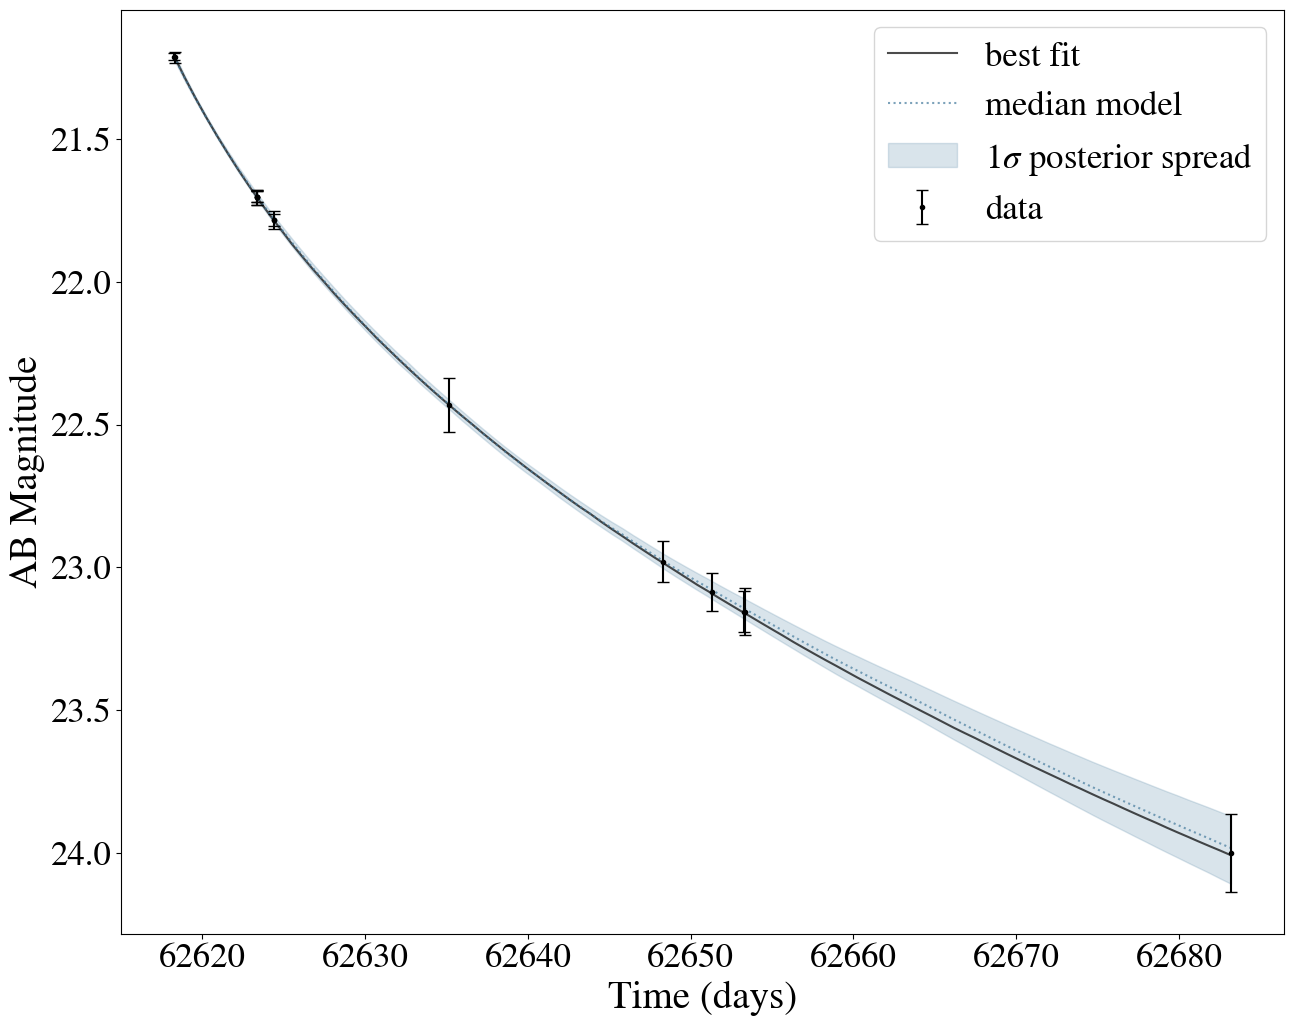

In [11]:
plt.rcParams.update({'font.size': 25})
plt.figure(figsize=(15,12))

t_fit = np.linspace(min(t), max(t), num=100)

# median model and spread in posteriors for 100 samples
med_model, spread = sample_walkers(30, samples, nu)

# parameters of the max ln likelihood
best_params = samples[np.argmax(sampler.flatlnprobability)]
best_fit_model = model(t_fit, nu, best_params)

plt.plot(t_fit, flux_to_mag(best_fit_model), color="k", alpha=0.7, label='best fit')
plt.plot(t_fit, flux_to_mag(med_model), color="#457b9d", alpha=0.7, label='median model', ls=':')
plt.fill_between(t_fit, flux_to_mag(med_model - spread), flux_to_mag(med_model + spread), color="#457b9d", alpha=0.2,
                 label=r'$1\sigma$ posterior spread')

plt.errorbar(t, flux_to_mag(y), yerr=mags_err[mags < oa['mags_lim']], fmt=".k", capsize=4, label='data')

plt.xlabel('Time (days)', fontsize=28)
plt.ylabel('AB Magnitude', fontsize=28)
plt.gca().invert_yaxis()

plt.legend()
#plt.savefig('../figures/example_MCMC_orphan_fit.pdf', format="pdf", bbox_inches="tight", transparent=True)

plt.show()

## Check the 2D posteriors

In [12]:
Time(oa['grb_time']).mjd

62608.622838958334

In [13]:
best_params

array([6.26082348e+04, 5.19731683e+01, 6.18582147e-01, 3.71594056e-01,
       6.02598257e-01, 9.67548631e-01])

In [14]:
names = ['T0', 'log10E0', 'thetaObs', 'thetaCore', 'thetaWing', 'log10n0']
labels = labels = ['T_0', r'log_{10}(E_0)', r'\theta_{obs}', r'\theta_c', r'\theta_w', r'log_{10}(n_0)']

settings={'mult_bias_correction_order':0, 'smooth_scale_2D':4, 'smooth_scale_1D':4, 'boundary_correction_order':0}

samples_triangle = MCSamples(
    samples=samples,
    names=names,
    labels=labels,
    settings=settings
)

Removed no burn in


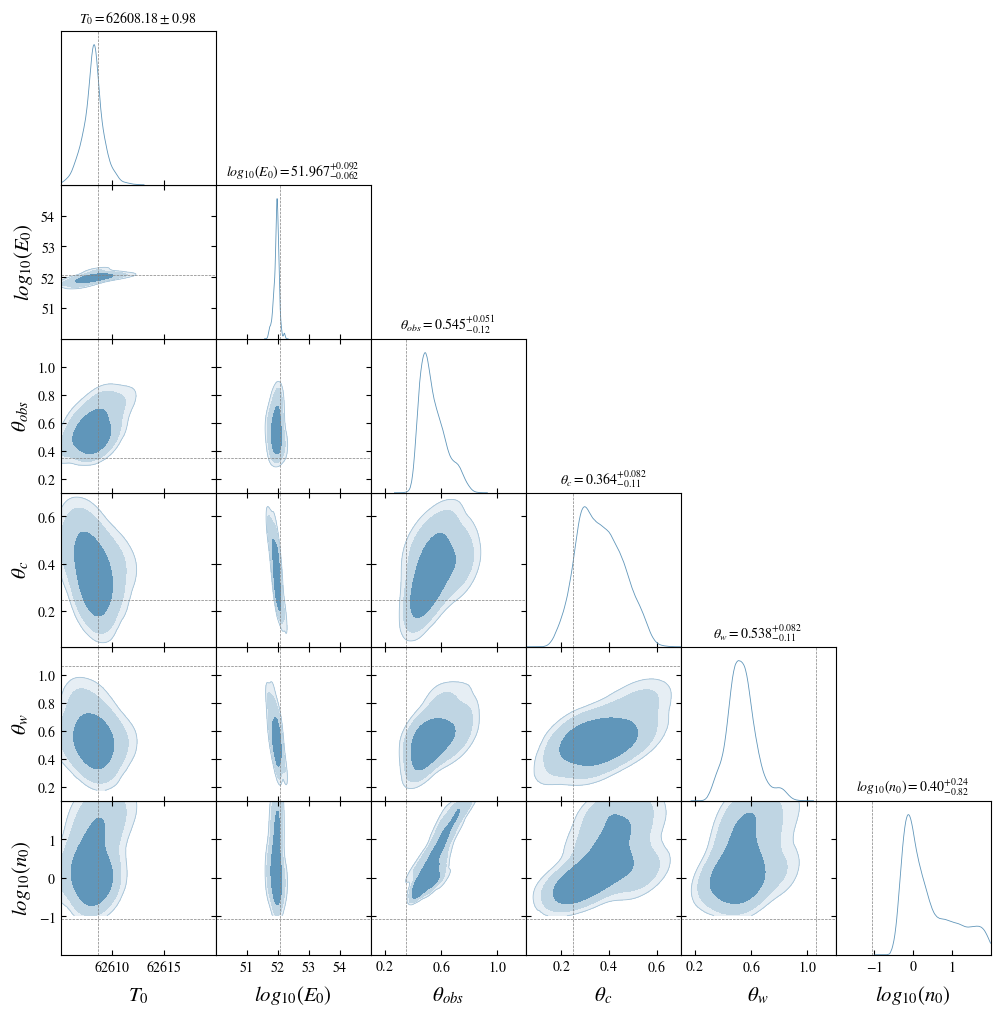

In [15]:
g = plots.get_subplot_plotter()
g.settings.num_plot_contours = 3
g.settings.axes_fontsize = 13 
g.settings.lab_fontsize = 18
g.settings.title_limit_fontsize = 13 
g.triangle_plot(samples_triangle, filled=True, contour_colors=['#6096ba'], title_limit=1,
                markers={'T0': Time(oa['grb_time']).mjd,
                         'log10E0': np.log10(oa['config']['E0']),
                         'thetaObs': oa['config']['thetaObs'],
                         'thetaCore': oa['config']['thetaCore'],
                         'thetaWing': oa['config']['thetaWing'],
                         'log10n0': np.log10(oa['config']['n0'])},
                param_limits={'T0': (62605, 62620),
                      'log10E0': (50,55),
                      'thetaObs': (0.1, 1.2),
                      'thetaCore': (0.05, 0.7),
                      'thetaWing': (0.1, 1.2),
                      'log10n0': (-2, 2)})

#plt.savefig('../figures/fit_triangle_plot.pdf', format="pdf", bbox_inches="tight", transparent=True)

## Test with an "orphan" found in DP1

In [16]:
def flux_to_mag(flux):
    """ Convert flux from milliJansky to AB Magnitude

    1 Jy = 1e-23 erg/cm2/s/Hz
    Fnu = 3631 Jy = 3.631*1e-20 erg/cm2/s/Hz
    ABmag = 0-2.5*log10( Fnu )-48.6 = 0

    :param flux: flux in milli-Jansky
    :return: mag: as the AB Magnitude
    """

    mag = -2.5 * np.log10(flux * 1.0e-26) - 48.6
    return mag


def mag_to_flux(mag):
    """ Convert flux from AB Magnitude to milliJansky

    1 Jy = 1e-23 erg/cm2/s/Hz
    Fnu = 3631 Jy = 3.631*1e-20 erg/cm2/s/Hz
    ABmag = 0-2.5*log10( Fnu )-48.6 = 0

    :param mag: as the AB Magnitude
    :return: flux: flux in milli-Jansky
    """

    flux = pow(10, (26 - (mag + 48.6) / 2.5))
    return flux


def model(t, nu, params):
    """ Model used to fit, implemented here in the afterglowpy package
    """

    # dictionary containing the fixed parameters
    Z = {'jetType': 4,
         'specType': 0,
         'b': 4,
         'p': 2.2,
         'epsilon_e': 0.1,
         'epsilon_B': 0.01,
         'xi_N': 1.0}

    # parameters to fit (we don't know z this time)
    T0, logE, thetaObs, thetaCore, thetaWing, logn, z = params

    return grb.fluxDensity((t - T0) * grb.day2sec, nu, E0=10**logE, thetaObs=thetaObs, thetaCore=thetaCore,
                           thetaWing=thetaWing, n0=10**logn, z=z, d_L=cosmo.luminosity_distance(z).value * 3.08e24, **Z)


def lnlike(p, t, y, yerr):
    """ Compute ln of likelihood
    """

    return -0.5 * np.sum(((y - model(t, nu, p)) / yerr) ** 2)


def lnprior(p):
    """ Compute ln of parameters priors
    """

    T0, logE, thetaObs, thetaCore, thetaWing, logn, z = p

    # uniform priors
    if (t[0] - 200. < T0 < t[0] - 1. and 51. < logE < 55. and 0.0 < thetaCore < np.pi / 2 and thetaCore < thetaWing < np.pi / 2 and 0. < thetaObs < np.pi/2 
        and -2 < logn < 2 and 0.01 < z < 2.):
        return (0.0)

    return (-np.inf)


def lnpost(p, t, y, yerr):
    """ Compute ln of parameters posteriors
    """

    lp = lnprior(p)

    return lp + lnlike(p, t, y, yerr) if np.isfinite(lp) else -np.inf


def sample_walkers(nsamples, flattened_chain, nu):
    """ Compute the median model and the spread in posteriors of the MCMC
    """

    models = []
    draw = np.floor(np.random.uniform(0, len(flattened_chain), size=nsamples)).astype(int)
    thetas = flattened_chain[draw]

    for i in thetas:
        mod = model(t_fit, nu, i)
        models.append(mod)

    spread = np.std(models, axis=0)
    med_model = np.median(models, axis=0)

    return med_model, spread

In [23]:
all_mean_nu = [840336134453781.4, 629326620516047.8, 482703137570394.2, 397614314115308.1, 344530577088716.56,
               298760145396604.1]

# DP1 orphan data
df = pd.read_csv('../data/dp1_orphan_data.txt', sep=' ')

t = np.array(df['t[mjd]'])
y = np.array(df['flux[nJy]'])*1e-6   # convert in mJy
yerr = np.array(df['flux_err[nJy]'])*1e-6 # convert in mJy

data = (t, y, yerr)

# r-band mean frequency in Hzz
nu = np.array(t.shape)
nu[:] = all_mean_nu[2]


nwalkers = 30

if len(t) > 0:
    initial = np.array([t[0] - 10., 52., 0.3, 0.1, 0.2, 0., 0.1])
    ndim = len(initial)

    # initial position vector
    p0 = [np.array(initial) + 1e-2 * np.random.randn(ndim) for i in range(nwalkers)]
    sampler = emcee.EnsembleSampler(nwalkers, ndim, lnpost, args=data)
    print(sampler)

    print("Running burn-in...")
    p0, _, _ = sampler.run_mcmc(p0, 1000, progress=True);
    sampler.reset()

    print("Running production...")
    sampler.run_mcmc(p0, 3000, progress=True);

    print("Done!")

    samples = sampler.flatchain

    best_params = samples[np.argmax(sampler.flatlnprobability)]
    print(best_params)

Running burn-in...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [07:12<00:00,  2.31it/s]


Running production...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [18:50<00:00,  2.65it/s]

Done!
[6.06468255e+04 5.30248664e+01 4.75637658e-01 3.10968582e-01
 3.69560923e-01 1.33656428e+00 1.29773411e+00]


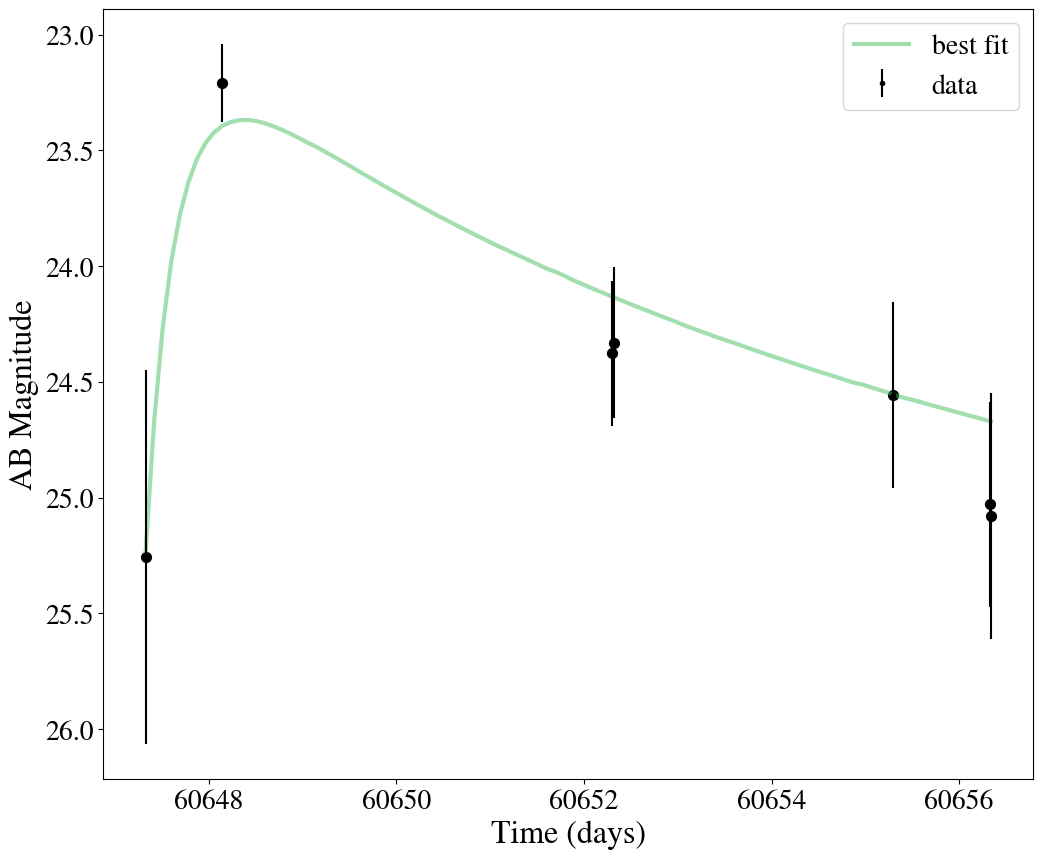

In [24]:
plt.rcParams.update({'font.size': 20})
plt.figure(figsize=(12,10))

t_fit = np.linspace(min(t), max(t), num=100)

# median model and spread in posteriors for 100 samples
med_model, spread = sample_walkers(30, samples, nu)

# parameters of the max ln likelihood
best_params = samples[np.argmax(sampler.flatlnprobability)]
best_fit_model = model(t_fit, nu, best_params)

mags = flux_to_mag(y)
mags_err = np.array((2.5 / np.log(10)) * yerr / y)

plt.plot(t_fit, flux_to_mag(best_fit_model), alpha=0.5, lw=3, color='#49be61', label='best fit')
#plt.plot(t_fit, flux_to_mag(med_model), color="#457b9d", alpha=0.7, label='median model', ls=':')
#plt.fill_between(t_fit, flux_to_mag(med_model - spread), flux_to_mag(med_model + spread), color="#457b9d", alpha=0.2,
                 #label=r'$1\sigma$ posterior spread')

plt.errorbar(t, mags, yerr=mags_err, fmt=".k", capsize=0, label='data')
plt.scatter(t, mags, s=50, color='k')

plt.xlabel('Time (days)', fontsize=23)
plt.ylabel('AB Magnitude', fontsize=23)
plt.gca().invert_yaxis()
#plt.ylim(27,21)

plt.legend()
#plt.savefig('../figures/comcam_MCMC_fit.pdf', format="pdf", bbox_inches="tight", transparent=True)

plt.show()

In [21]:
names = ['T0', 'log10E0', 'thetaObs', 'thetaCore', 'thetaWing', 'log10n0', 'z']
labels = labels = ['T_0', r'log_{10}(E_0)', r'\theta_{obs}', r'\theta_c', r'\theta_w', r'log_{10}(n_0)', 'z']

settings={'mult_bias_correction_order':0, 'smooth_scale_2D':4, 'smooth_scale_1D':4, 'boundary_correction_order':0}

samples_triangle = MCSamples(
    samples=samples,
    names=names,
    labels=labels,
    settings=settings
)

Removed no burn in


"                param_limits={'T0': (62605, 62620),\n                      'log10E0': (50,55),\n                      'thetaObs': (0.1, 1.2),\n                      'thetaCore': (0.05, 0.7),\n                      'thetaWing': (0.1, 1.2),\n                      'log10n0': (-2, 2)})"

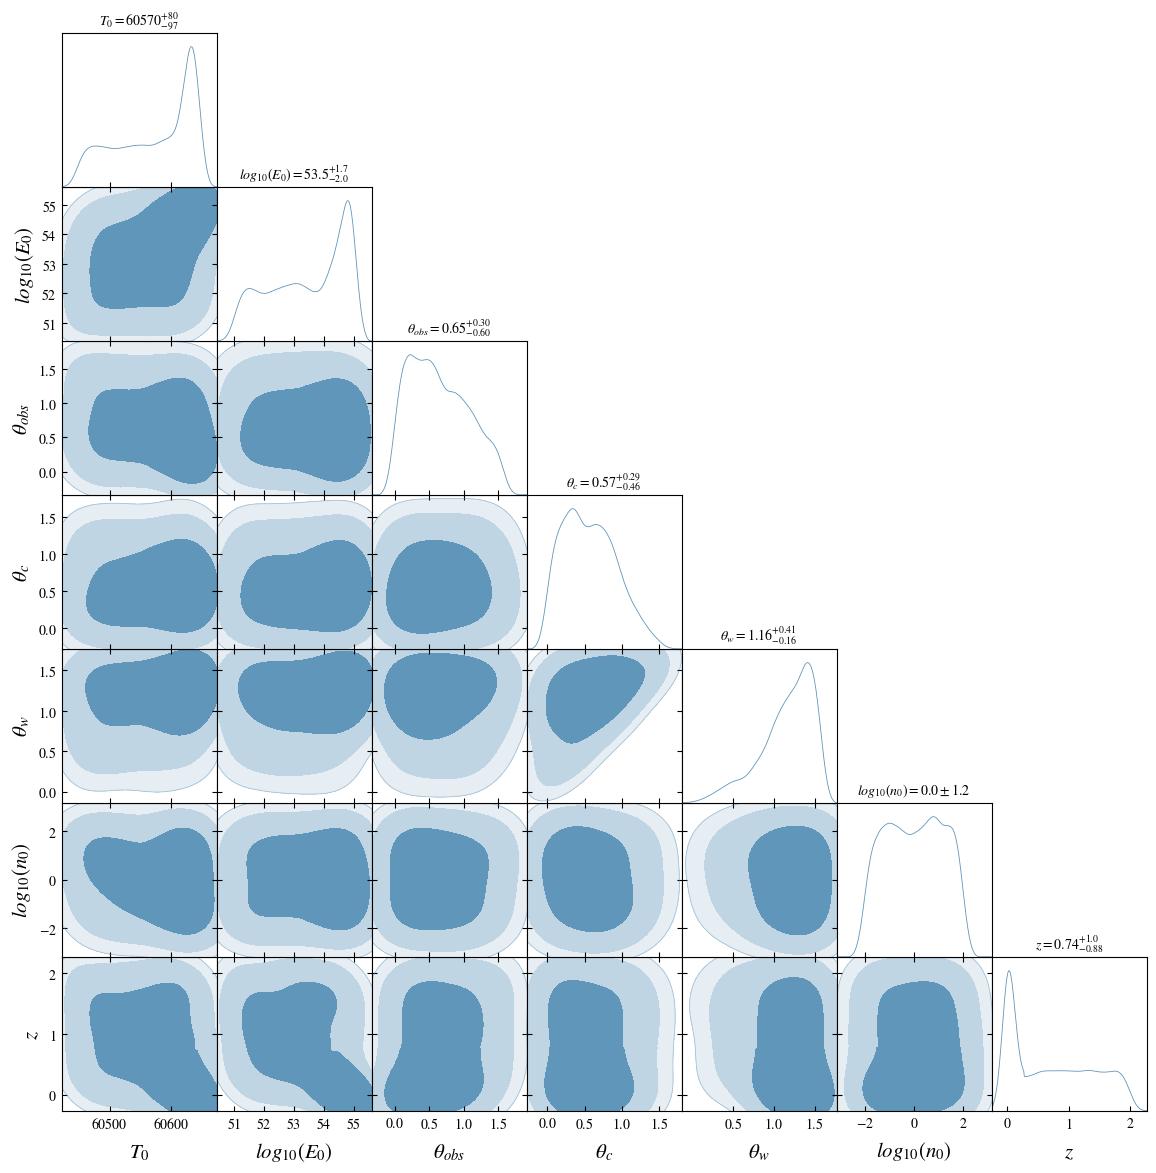

In [22]:
g = plots.get_subplot_plotter()
g.settings.num_plot_contours = 3
g.settings.axes_fontsize = 13 
g.settings.lab_fontsize = 18
g.settings.title_limit_fontsize = 13 
g.triangle_plot(samples_triangle, filled=True, contour_colors=['#6096ba'], title_limit=1)